In [41]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import h5py
import haversine as hs

In [42]:
data1 = np.load('Data/melt_rates/SOhi-v2/SOhi_v2_OctNovDec2007_MR.npy')
data1 = -data1 * 60 * 60 * 24 * 365 / 917
data2 = np.load('Data/melt_rates/rignot-2013/SOhiGrid_m-yr.npy')
data3 = np.load('Data/melt_rates/adusumilli-2020/SOhiGrid_m-yr.npy')

In [43]:
GRID = h5py.File('Data/SOhi_meta/SOhi_v1_GRID_v8.mat')
XC = np.asarray(GRID['XC'][0,:])
XC = ((XC + 180) %360) - 180

YC = np.asarray(GRID['YC'][:2344,0])

XG = np.asarray(GRID['XG'][0,:])
XG = ((XG + 180) %360) - 180

YG = np.asarray(GRID['YG'][:2344,0])

In [44]:
BATH = np.load('Data/SOhi_meta/SOhi_v2-Bathymetry.npy')

In [45]:
def gencoords(x_points, y_points, resolution):
    
    DISTANCE = []
    POINTS = []
    
    for i in range(len(x_points) -1): #iterate through point pairs
        point1 = [x_points[i], y_points[i]] 
        point2 = [x_points[i+1], y_points[i+1]]
        
        if point1[0] == point2[0]: ## Identical X, Longitude slice
            dx = 0
            dy = 1
            slope = None 
            b = None
            
        elif point1[1] == point2[1]: ## Identical Y, Latitude Slice
            dx = 1
            dy = 0
            slope = None
            b = None
            
        else:## Calc line equation
            slope = (point2[1] - point1[1])/(point2[0] - point1[0])
            b = -(slope * point1[0]) + point1[1]  
            
            ## Find difference between dx and dy
            xend = point2[0]
            xstart = point1[0]
            yend = point2[1]
            ystart = point1[1]

            dx = np.abs(xend - xstart)
            dy = np.abs(yend - ystart)
            
            
            
        ### coordinates is between 180 to 360
        if np.min([x_points[i], x_points[i+1]]) > 180:
            total_dist = hs.haversine((point1[1],((point1[0] + 180) % 360) - 180), 
                              (point2[1], ((point2[0] + 180) % 360) - 180), unit=hs.Unit.METERS)
            num_pix = int(total_dist/resolution)
            
            
            
        elif np.max([x_points[i], x_points[i+1]]) < 180: ## coordinates is between -180 and 180
            
            total_dist = hs.haversine((point1[1],point1[0]), 
                              (point2[1], point2[0]), unit=hs.Unit.METERS)
            num_pix = int(total_dist/resolution)
            
        else: ## Coordinates crosses -180|180 boundary
            print('Not implemented. Too lazy. Setting resolution to 1000 and calling it a day')
            num_pix = 1000
            
          
        dm = []
        
        if dx > dy: ## dx sampling
                
            ## Get coordinates at boundary
            lon_arr = np.linspace(point1[0], point2[0], num_pix+1, endpoint=True)
            if slope is not None:
                lat_arr = [(i*slope) + b for i in lon_arr]
            else:
                lat_arr = [point1[1] for i in lon_arr]
                
                
            convert_back = False
            if np.max(lon_arr) > 180:
                convert_back = True
                lon_arr = ((lon_arr + 180) % 360) - 180
            
            ## Convert coordinates into distance
            for ii in range(num_pix): ## Calc distance between sampling points 
                meters = hs.haversine((lat_arr[ii],lon_arr[ii]), 
                              (lat_arr[ii+1],lon_arr[ii+1]), unit=hs.Unit.METERS)
                dm.append(meters)
                
            if convert_back:
                lon_arr = lon_arr % 360
                
            ## Convert Boundary coordinates into Center Coordinates
            temp1 = []
            temp2 = []
            for ii in range(len(lon_arr)-1):
                temp1.append((lon_arr[ii] + lon_arr[ii+1])/2)
                temp2.append((lat_arr[ii] + lat_arr[ii])/2)
            lon_arr = np.asarray(temp1)
            lat_arr = np.asarray(temp2)

        elif dy >= dx: # dy sampling
                
            ## Get coordinates at boundary
            lat_arr = np.linspace(point1[1], point2[1], num_pix+1, endpoint=True)
            if slope is not None:
                lon_arr = [(i-b)/slope for i in lat_arr]
            else:
                lon_arr = [point1[0] for i in lat_arr]
                
            lon_arr = np.asarray(lon_arr) 
            
            convert_back = False
            if np.max(lon_arr) > 180:
                convert_back = True
                lon_arr = ((lon_arr + 180) % 360) - 180
                
            ## Convert coordinates into distance
            for ii in range(num_pix):
                meters = hs.haversine((lat_arr[ii],lon_arr[ii]), 
                              (lat_arr[ii+1],lon_arr[ii+1]), unit=hs.Unit.METERS)
                dm.append(meters)
                
            if convert_back:
                lon_arr = lon_arr % 360
                
            ## Get coordinates at center
            temp1 = []
            temp2 = []
            for ii in range(len(lat_arr)-1):
                temp1.append((lat_arr[ii] + lat_arr[ii+1])/2)
                temp2.append((lon_arr[ii] + lon_arr[ii+1])/2)
            lat_arr = np.asarray(temp1)
            lon_arr = np.asarray(temp2)
            
        for j in range(len(lat_arr)):
            DISTANCE.append(dm[j])
            POINTS.append([lat_arr[j], lon_arr[j]])
            
    DISTANCE = np.asarray(DISTANCE)
    DISTANCE = np.cumsum(DISTANCE) / 1000
    
    return DISTANCE, np.asarray(POINTS)

In [46]:
def to_index(coords, YC, XC):
    points = []
    for i in range(len(coords)):
        iy = np.argmin(abs(YC-coords[i,0]))
        
        ix = np.argmin(abs(XC-coords[i,1]))
        
        points.append([iy,ix])
    
    return np.asarray(points)

In [47]:
def sample(field, indices, w):
    res = np.zeros(len(indices))
    for i in range(len(indices)):
        try:
            sample = field[indices[i,0]-w:indices[i,0]+w+1, indices[i,1]-w:indices[i,1]+w+1]
            res[i] = np.nanmean(sample)
        except:
            print(indices[i,0], indices[i,1])
            
    return res

### pine island

In [34]:
np.argmin(abs(XC - -104)), np.argmin(abs(XC - -98)), np.argmin(abs(YC - -76)), np.argmin(abs(YC - -74.2))

(np.int64(6143), np.int64(6287), np.int64(1046), np.int64(1214))

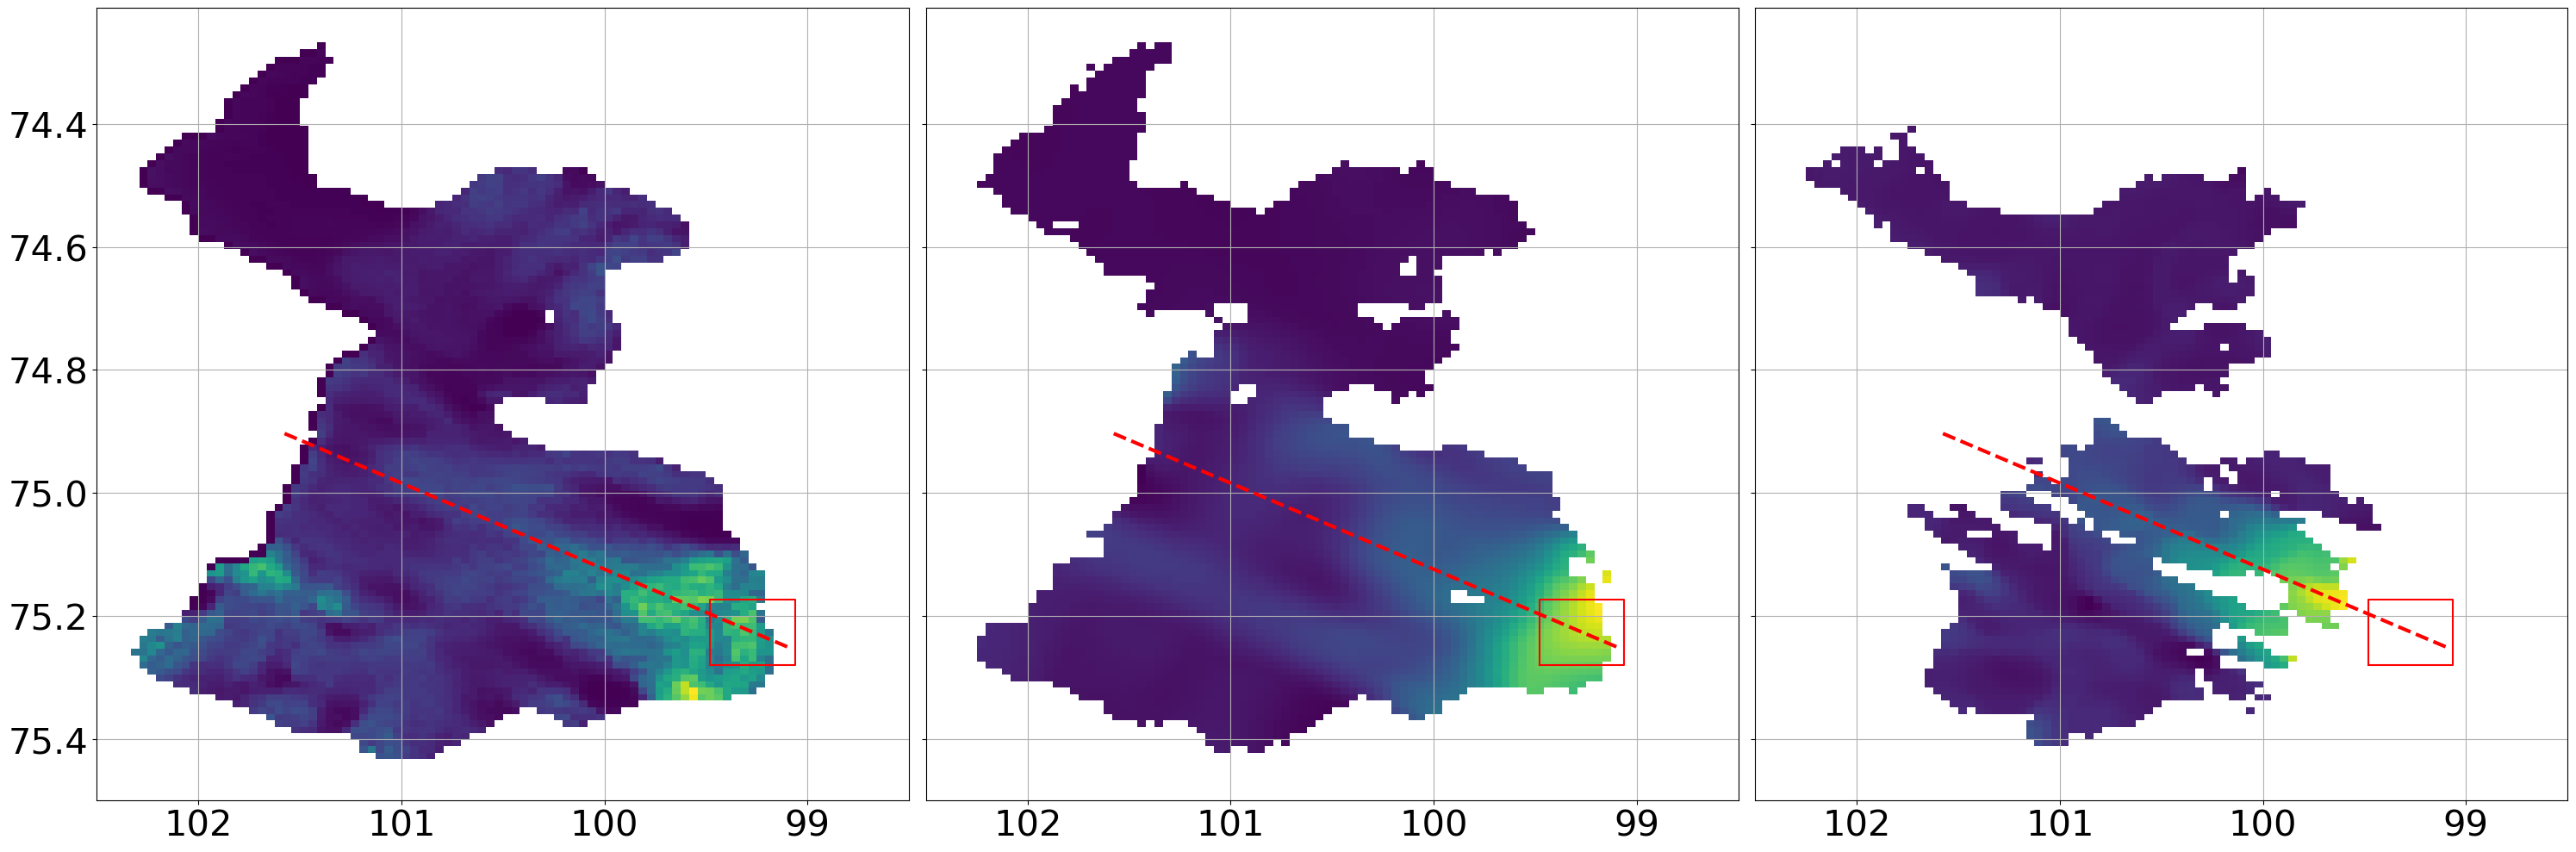

In [175]:
fig, ax = plt.subplots(figsize=(30,10), ncols=3, sharey=True)

ax[0].pcolormesh(XC[6143:6287], YC[1046:1214], data1[1046:1214, 6143:6287])
ax[1].pcolormesh(XC[6143:6287], YC[1046:1214], data2[1046:1214, 6143:6287])
ax[2].pcolormesh(XC[6143:6287], YC[1046:1214], data3[1046:1214, 6143:6287])

lons = [-99.1, -101.6]
lats = [-75.25, -74.9]

for i in ax.flat:
    i.plot(lons, lats, '--', c='red', lw=3,)
    i.grid()

    i.set_ylim(-75.5)
    i.set_xlim(-102.5, -98.5)

l = 10
x1 = XC[indices[l,1]-w]
x2 = XC[indices[l,1]+w]
y1 = YC[indices[l,0]-w]
y2 = YC[indices[l,0]+w]

for i in ax.flat:
    i.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], c='red')
    i.tick_params(labelsize=30)

    i.set_xticks([-102, -101, -100, -99])
    i.set_xticklabels([102, 101, 100, 99])
    i.set_yticks([-74.4, -74.6, -74.8, -75, -75.2, -75.4])
    i.set_yticklabels([74.4, 74.6, 74.8, "75.0", 75.2, 75.4])
    
plt.tight_layout()

plt.savefig('Figures/Fig03/PIG_region.png', dpi=300)

In [176]:
dist, points = gencoords(lons, lats, 500)
indices = to_index(points, YC, XC)
indices.shape

(162, 2)

In [177]:
w = 5
slice1 = sample(data1, indices, w=w)
slice2 = sample(data2, indices, w=w)
slice3 = sample(data3, indices, w=w)

/var/folders/2n/5cjcyrz92xq2s13y29jhm27w0000gn/T/ipykernel_19949/3814149161.py:6: RuntimeWarning: Mean of empty slice
  res[i] = np.nanmean(sample)


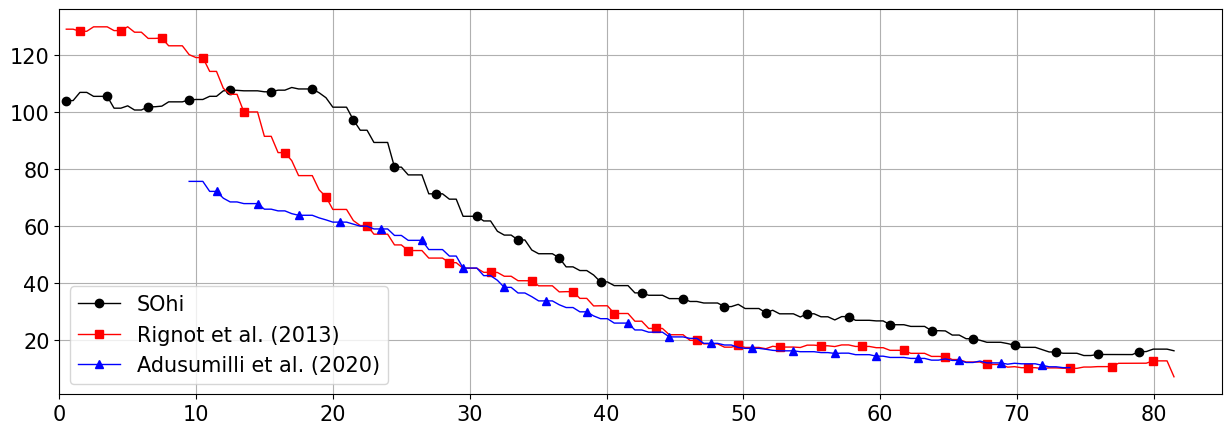

In [178]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(dist, slice1, c='k', marker='o', markevery=6, lw=1, label = 'SOhi')
ax.plot(dist, slice2, c='r', marker='s', markevery=(2,6), lw=1, label='Rignot et al. (2013)')
ax.plot(dist, slice3, c='b', marker='^', markevery=(4,6), lw=1, label='Adusumilli et al. (2020)')

ax.set_xlim(0, 85)
ax.tick_params(labelsize=15)
ax.grid()

ax.legend(fontsize=15, loc='lower left')

plt.savefig('Figures/Fig03/PIG_data.png', dpi=300)

### Thwaites

In [63]:
np.argmin(abs(XC - -110)), np.argmin(abs(XC - -102)), np.argmin(abs(YC - -76)), np.argmin(abs(YC - -73))

(np.int64(5999), np.int64(6191), np.int64(1046), np.int64(1317))

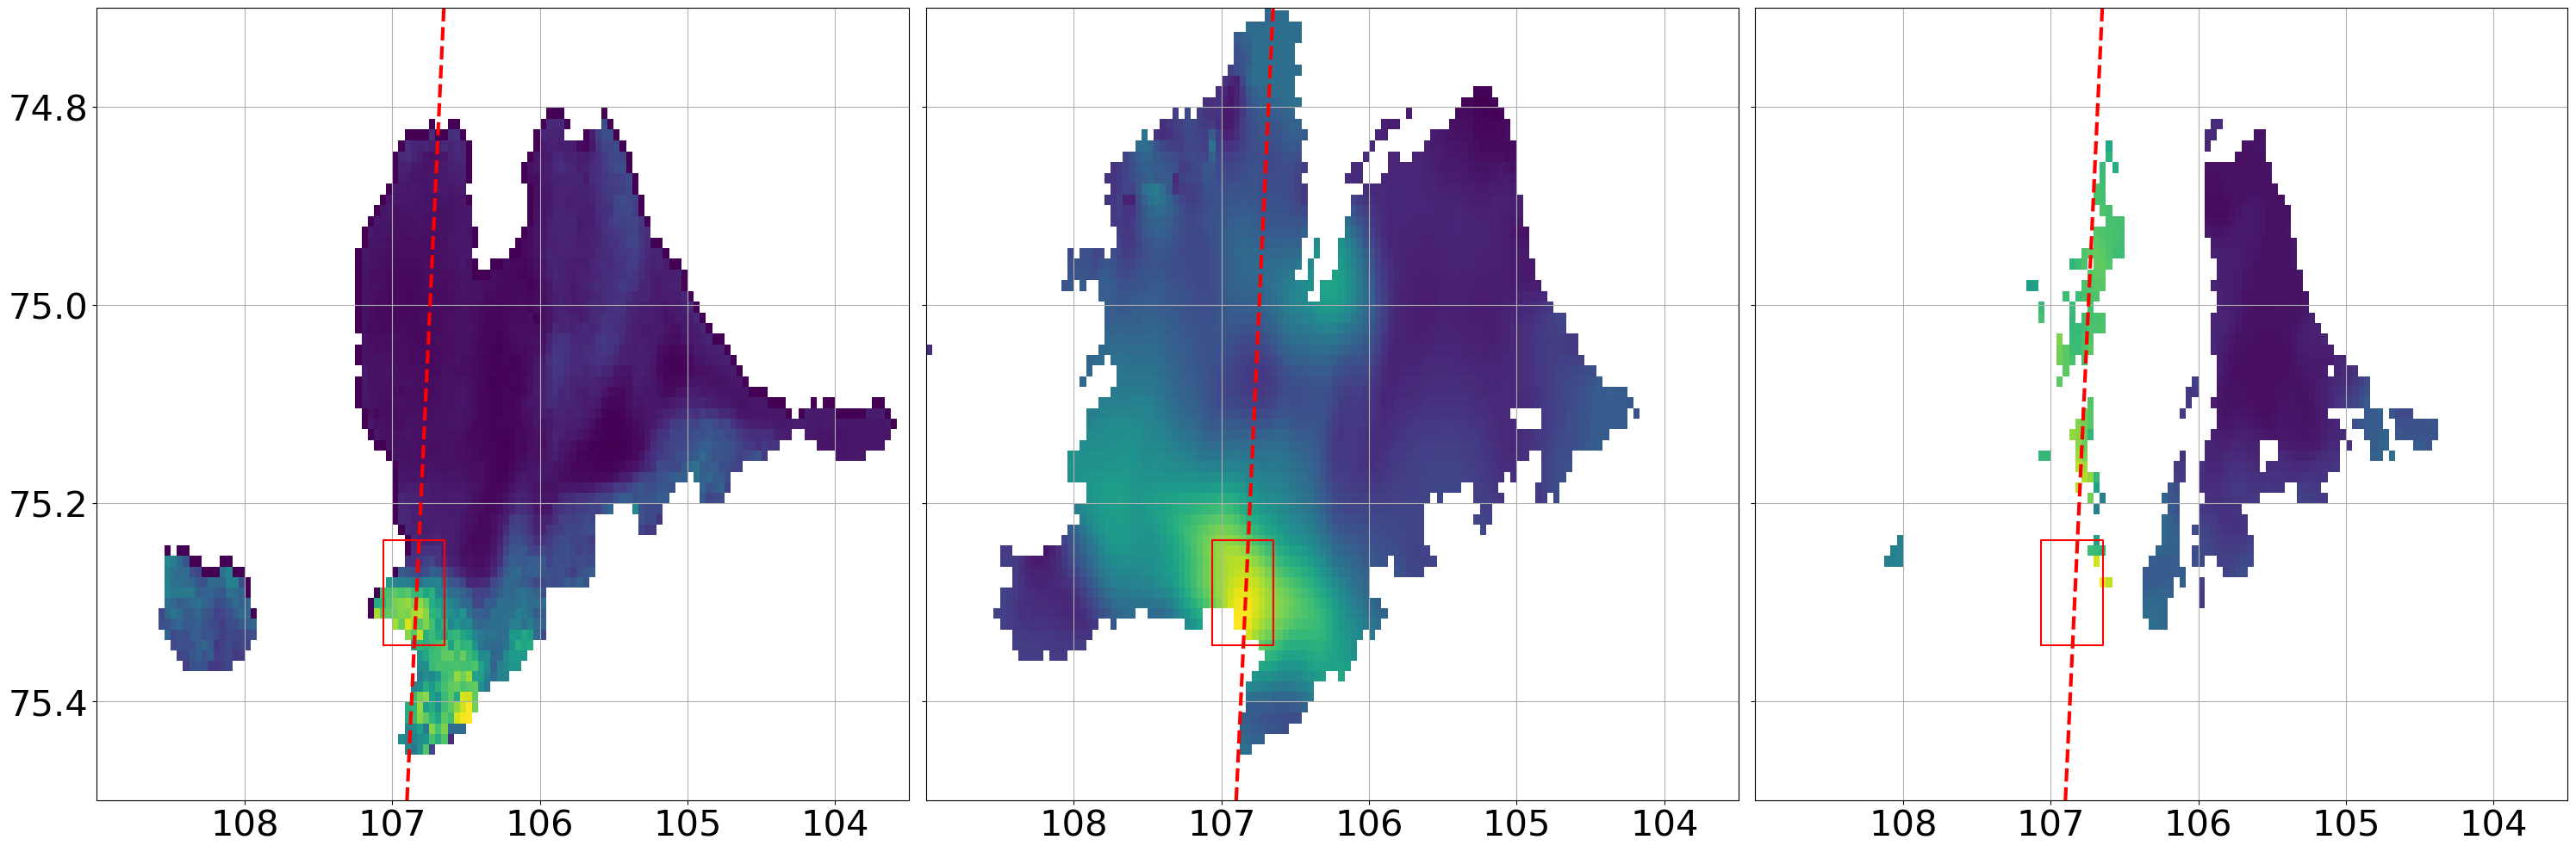

In [67]:
fig, ax = plt.subplots(figsize=(30,10), ncols=3, sharey=True)

ax[0].pcolormesh(XC[5999:6191], YC[1046:1317], data1[1046:1317, 5999:6191])
ax[1].pcolormesh(XC[5999:6191], YC[1046:1317], data2[1046:1317, 5999:6191])
ax[2].pcolormesh(XC[5999:6191], YC[1046:1317], data3[1046:1317, 5999:6191])

lons = [-106.9, -106.65]
lats = [-75.5, -74.7]

for i in ax.flat:
    i.plot(lons, lats, '--', c='red', lw=3,)
    i.grid()

    i.set_ylim(-75.5, -74.7)
    i.set_xlim(-109, -103.5)

l = 46
x1 = XC[indices[l,1]-w]
x2 = XC[indices[l,1]+w]
y1 = YC[indices[l,0]-w]
y2 = YC[indices[l,0]+w]

for i in ax.flat:
    i.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], c='red')
    i.tick_params(labelsize=30)

    i.set_yticks([-74.8, -75, -75.2, -75.4])
    i.set_yticklabels(["74.8", "75.0", "75.2", "75.4"])
    i.set_xticks([-108, -107, -106, -105, -104])
    i.set_xticklabels([108, 107, 106, 105, 104])
    
plt.tight_layout()



plt.savefig('Figures/Fig03/TIS_region.png', dpi=300)

In [65]:
dist, points = gencoords(lons, lats, 500)
indices = to_index(points, YC, XC)
indices.shape

(178, 2)

In [66]:
w=5
slice1 = sample(data1, indices, w=w)
slice2 = sample(data2, indices, w=w)
slice3 = sample(data3, indices, w=w)

/var/folders/f8/s61qdz9n3pz5knzrxfklfwlh0000gn/T/ipykernel_7183/3814149161.py:6: RuntimeWarning: Mean of empty slice
  res[i] = np.nanmean(sample)


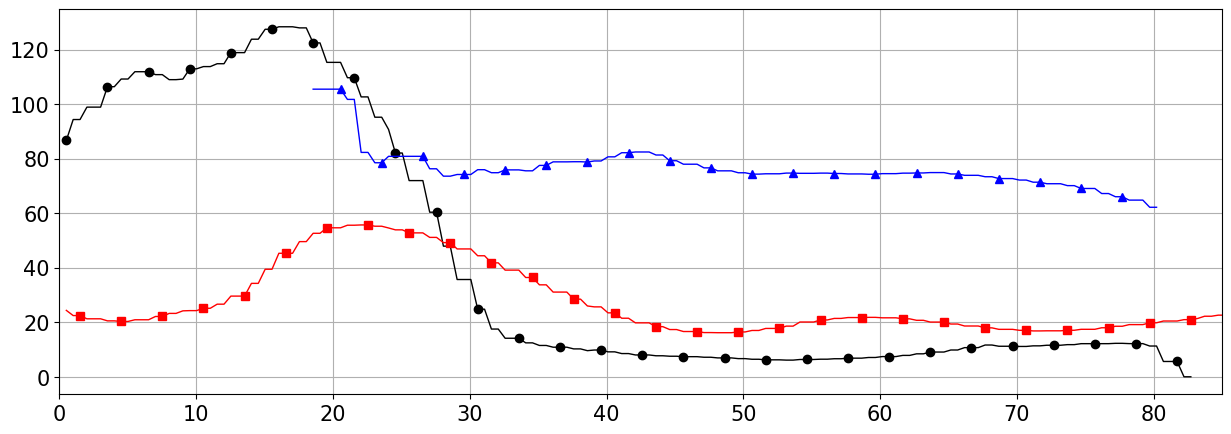

In [68]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(dist, slice1, c='k', marker='o', markevery=6, lw=1, label = 'SOhi')
ax.plot(dist, slice2, c='r', marker='s', markevery=(2,6), lw=1, label='Rignot et al. (2013)')
ax.plot(dist, slice3, c='b', marker='^', markevery=(4,6), lw=1, label='Adusumilli et al. (2020)')

ax.set_xlim(0, 85)
ax.tick_params(labelsize=15)
ax.grid()

# ax.legend(fontsize=15, loc='lower left')

plt.savefig('Figures/Fig03/TIS_data.png', dpi=300)

### Totten

In [56]:
lat = [-68, -66]
lon = [113.5, 118.6]

In [57]:
np.argmin(abs(XC - 113.5)), np.argmin(abs(XC - 118.6)), np.argmin(abs(YC - -68)), np.argmin(abs(YC - -66))

(np.int64(2723), np.int64(2846), np.int64(1678), np.int64(1801))

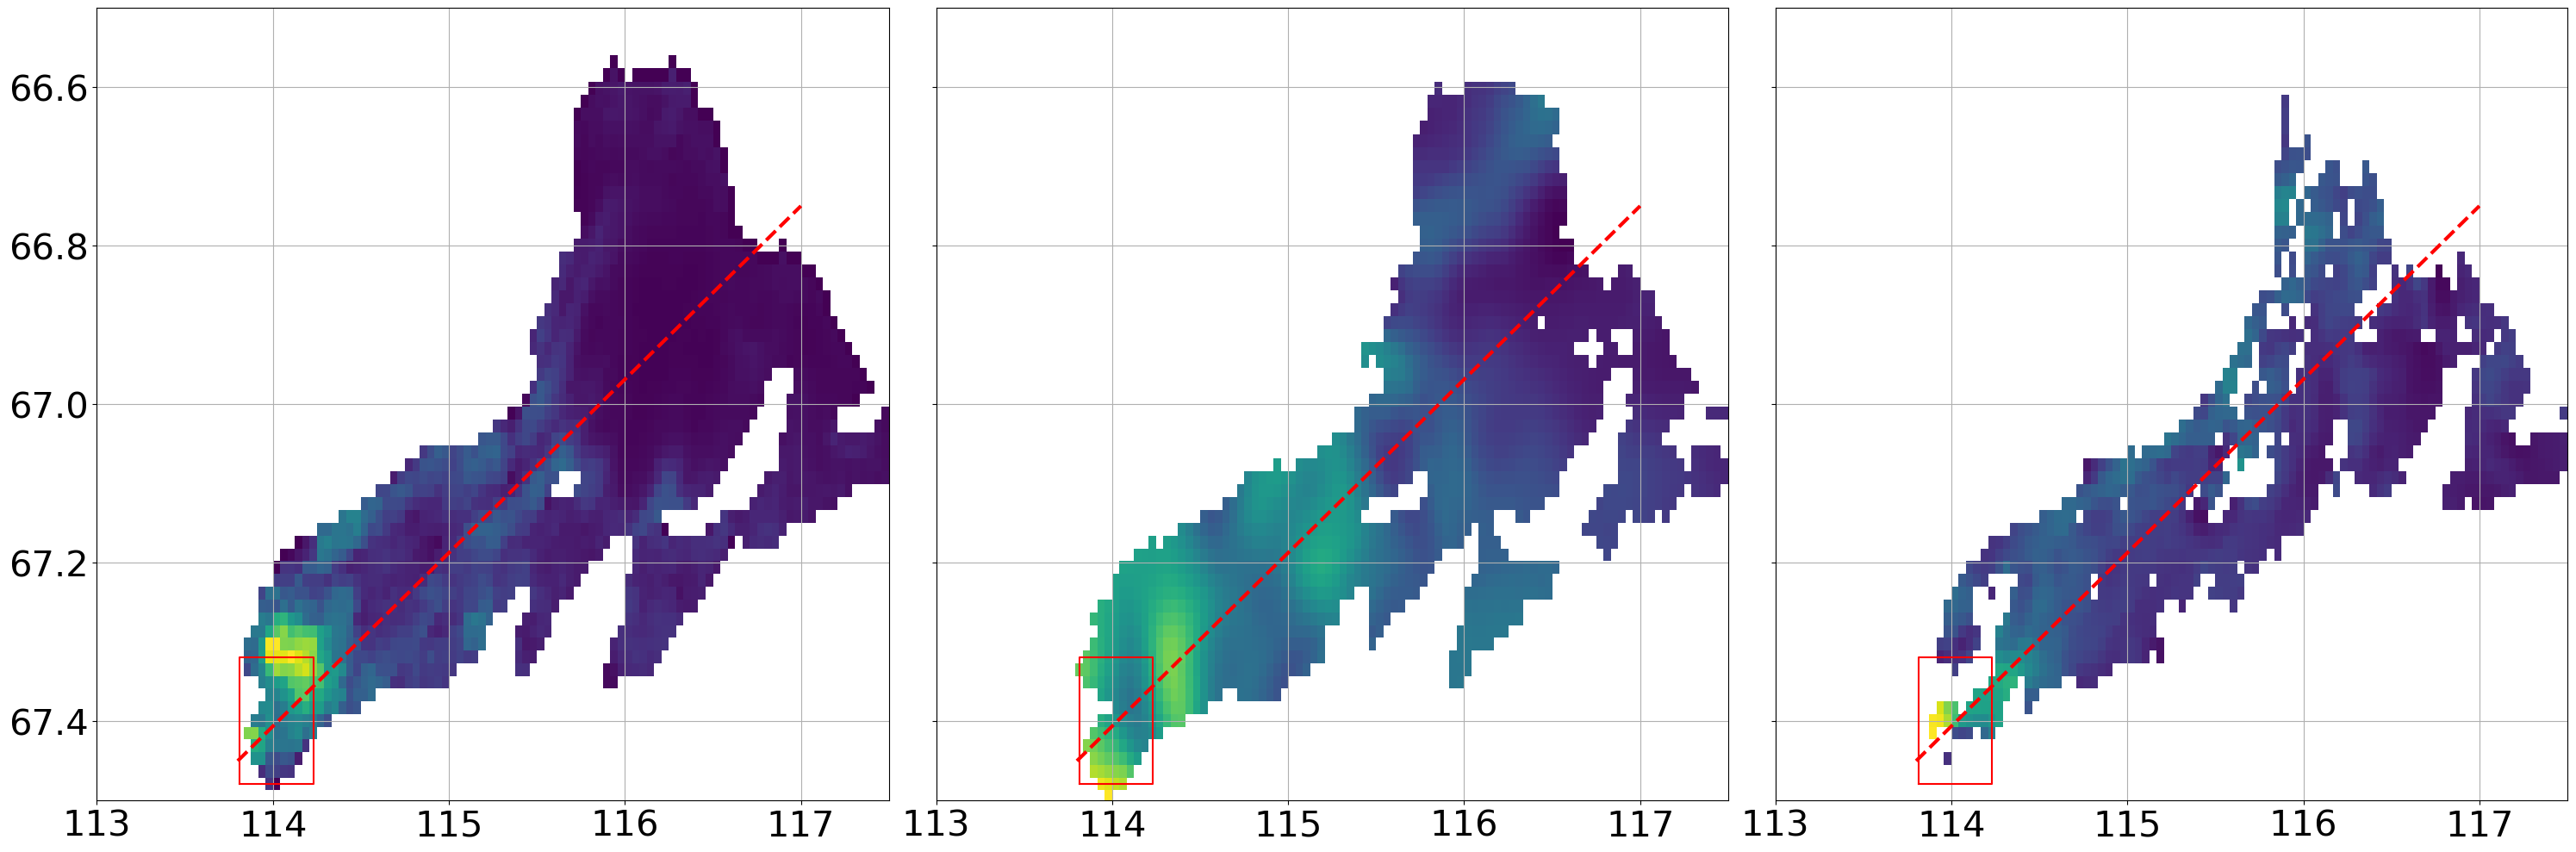

In [61]:
fig, ax = plt.subplots(figsize=(30,10), ncols=3, sharey=True)

ax[0].pcolormesh(XC[2723:2846], YC[1678:1801], data1[1678:1801, 2723:2846])
ax[1].pcolormesh(XC[2723:2846], YC[1678:1801], data2[1678:1801, 2723:2846])
ax[2].pcolormesh(XC[2723:2846], YC[1678:1801], data3[1678:1801, 2723:2846])

lons = [113.8, 117]
lats = [-67.45, -66.75]

for i in ax.flat:
    i.plot(lons, lats, '--', c='red', lw=3,)
    i.grid()

    i.set_ylim(-67.5, -66.5)
    i.set_xlim(113, 117.5)

l = 20
x1 = XC[indices[l,1]-w]
x2 = XC[indices[l,1]+w]
y1 = YC[indices[l,0]-w]
y2 = YC[indices[l,0]+w]

for i in ax.flat:
    i.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], c='red')
    i.tick_params(labelsize=30)

    i.set_yticks([-66.6, -66.8, -67, -67.2, -67.4])
    i.set_yticklabels([66.6, 66.8, "67.0", 67.2, 67.4])
    
plt.tight_layout()

plt.savefig('Figures/Fig03/Totten_region.png', dpi=300)

In [59]:
dist, points = gencoords(lons, lats, 500)
indices = to_index(points, YC, XC)
indices.shape

(317, 2)

In [60]:
w = 5
slice1 = sample(data1, indices, w=w)
slice2 = sample(data2, indices, w=w)
slice3 = sample(data3, indices, w=w)

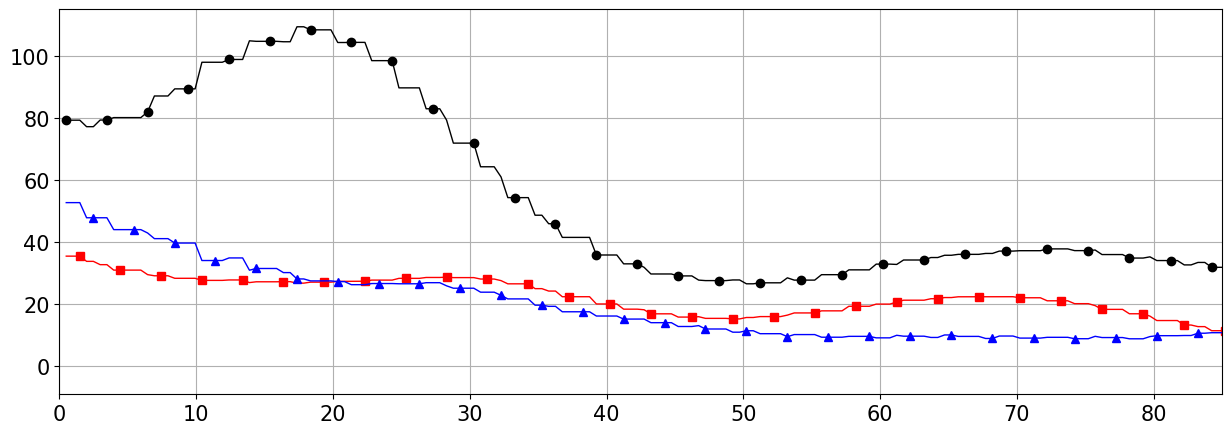

In [62]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(dist, slice1, c='k', marker='o', markevery=6, lw=1, label = 'SOhi')
ax.plot(dist, slice2, c='r', marker='s', markevery=(2,6), lw=1, label='Rignot et al. (2013)')
ax.plot(dist, slice3, c='b', marker='^', markevery=(4,6), lw=1, label='Adusumilli et al. (2020)')

ax.set_xlim(0, 85)
ax.tick_params(labelsize=15)
ax.grid()

# ax.legend(fontsize=15, loc='lower left')

plt.savefig('Figures/Fig03/Totten_data.png', dpi=300)

## Shackleton

In [48]:
lat = [-67.3, -64.8]
lon = [93, 104]

In [49]:
np.argmin(abs(XC - 93)), np.argmin(abs(XC - 104)), np.argmin(abs(YC - -67.3)), np.argmin(abs(YC - -64.8))

(np.int64(2231), np.int64(2495), np.int64(1722), np.int64(1870))

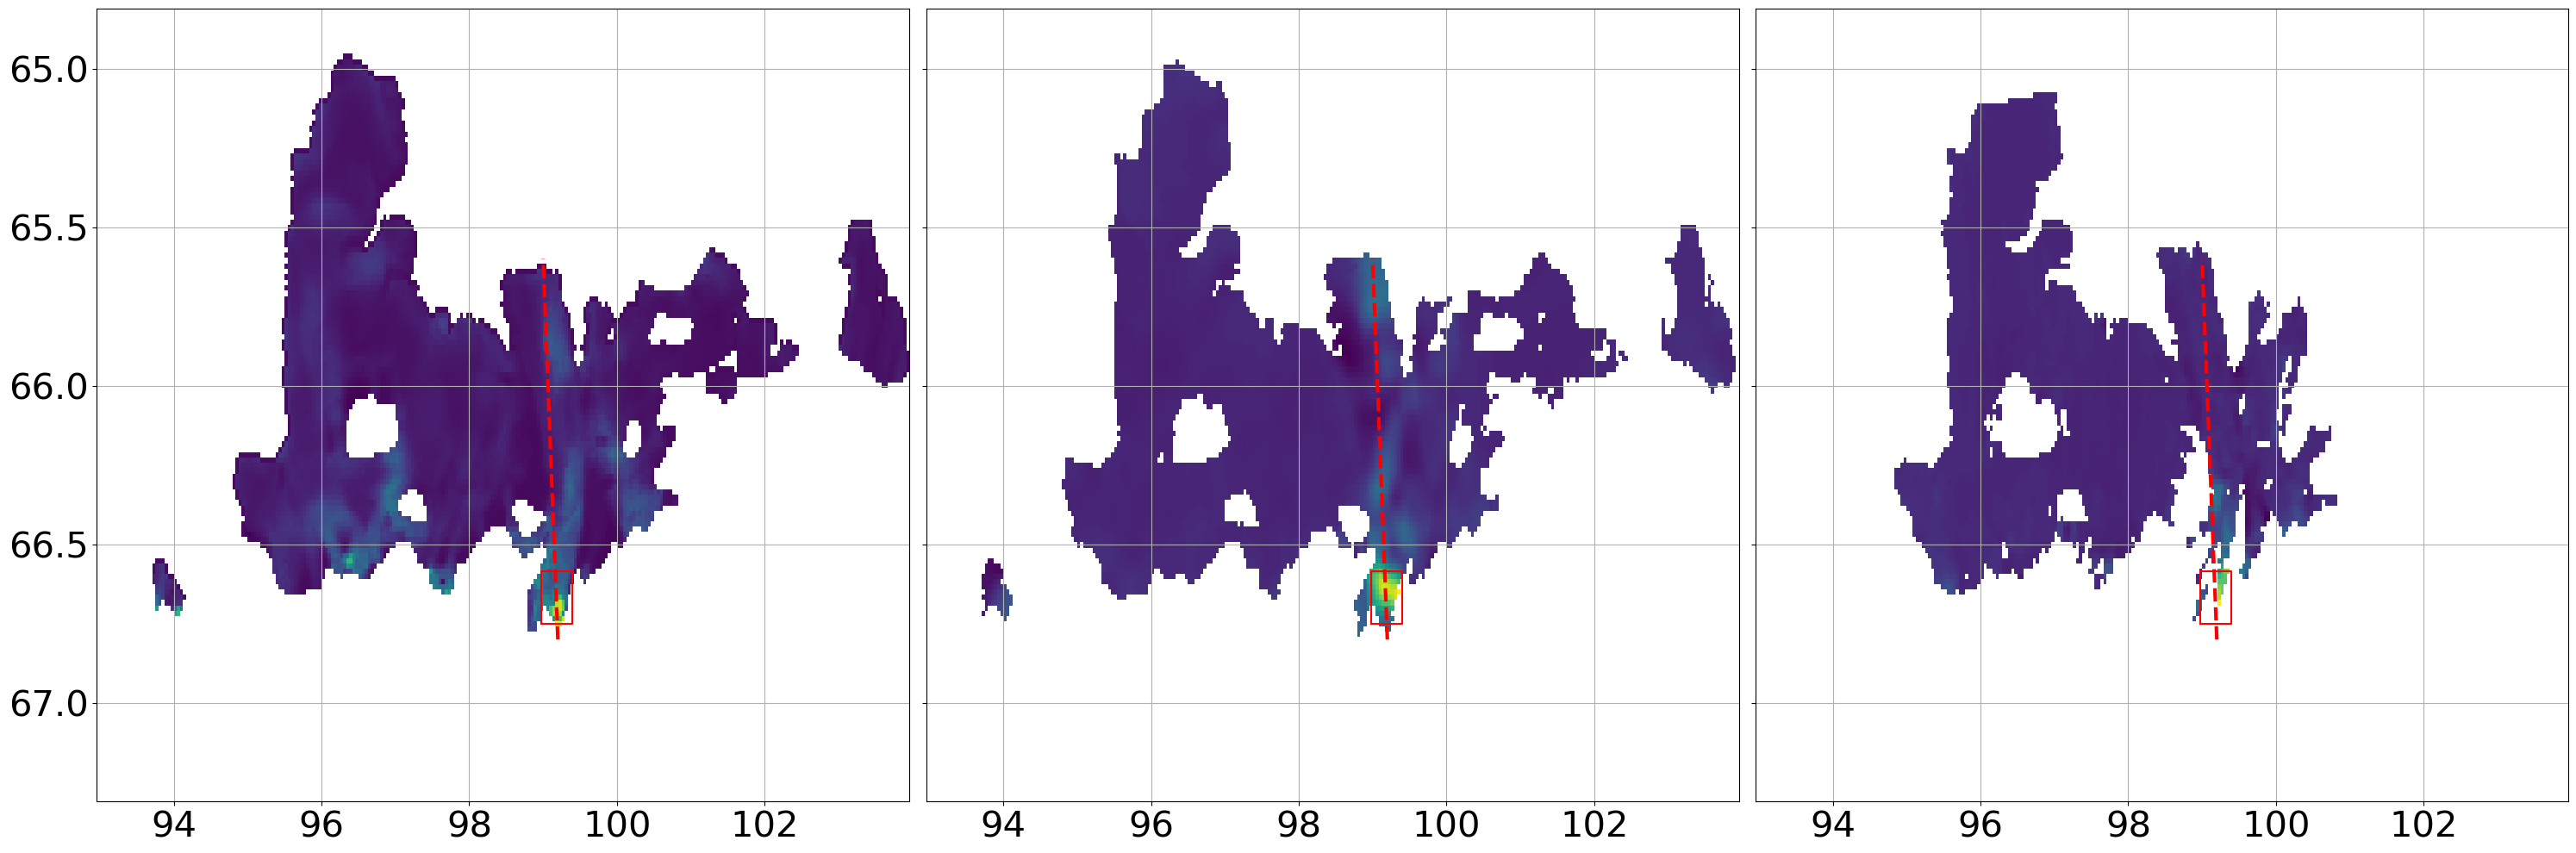

In [53]:
fig, ax = plt.subplots(figsize=(30,10), ncols=3, sharey=True)

ax[0].pcolormesh(XC[2231:2495], YC[1722:1870], data1[1722:1870, 2231:2495])
ax[1].pcolormesh(XC[2231:2495], YC[1722:1870], data2[1722:1870, 2231:2495])
ax[2].pcolormesh(XC[2231:2495], YC[1722:1870], data3[1722:1870, 2231:2495])

lons = [99.2, 99 ]
lats = [-66.8, -65.6]

for i in ax.flat:
    i.plot(lons, lats, '--', c='red', lw=3,)
    i.grid()

    # i.set_ylim(-75.6, -74.2)
    # i.set_xlim(-109, -103)

l = 30
x1 = XC[indices[l,1]-w]
x2 = XC[indices[l,1]+w]
y1 = YC[indices[l,0]-w]
y2 = YC[indices[l,0]+w]

for i in ax.flat:
    i.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], c='red')
    i.tick_params(labelsize=30)

    i.set_yticks([-65, -65.5, -66, -66.5, -67])
    i.set_yticklabels(["65.0", "65.5", "66.0", "66.5", "67.0"])
    
plt.tight_layout()

plt.savefig('Figures/Fig03/Shackleton_region.png', dpi=300)

In [51]:
dist, points = gencoords(lons, lats, 500)
indices = to_index(points, YC, XC)
indices.shape

(267, 2)

In [52]:
w = 5
slice1 = sample(data1, indices, w=w)
slice2 = sample(data2, indices, w=w)
slice3 = sample(data3, indices, w=w)

/var/folders/f8/s61qdz9n3pz5knzrxfklfwlh0000gn/T/ipykernel_7183/3814149161.py:6: RuntimeWarning: Mean of empty slice
  res[i] = np.nanmean(sample)


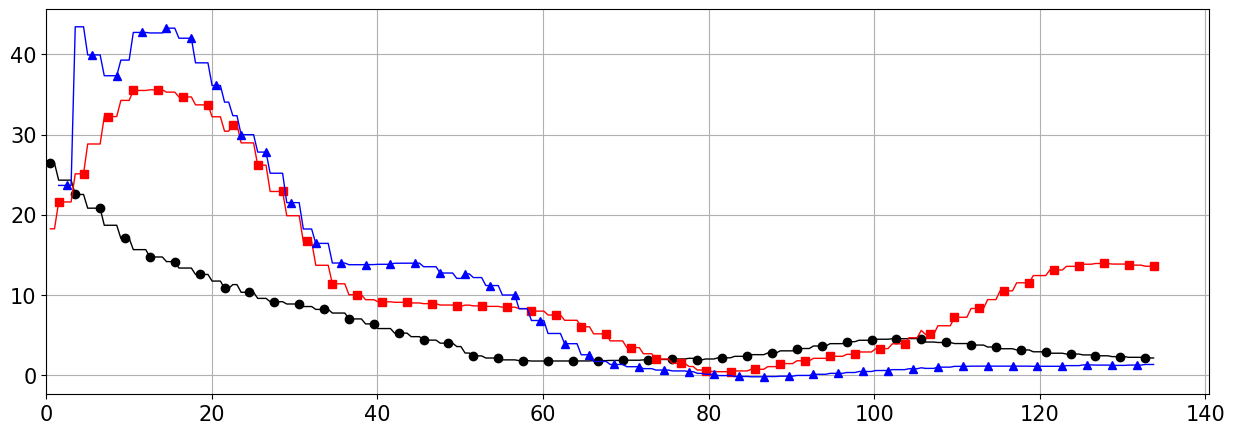

In [55]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(dist, slice1, c='k', marker='o', markevery=6, lw=1, label = 'SOhi')
ax.plot(dist, slice2, c='r', marker='s', markevery=(2,6), lw=1, label='Rignot et al. (2013)')
ax.plot(dist, slice3, c='b', marker='^', markevery=(4,6), lw=1, label='Adusumilli et al. (2020)')

ax.set_xlim(0)
ax.tick_params(labelsize=15)
ax.grid()

# ax.legend(fontsize=15, loc='lower left')

plt.savefig('Figures/Fig03/Shackleton_data.png', dpi=300)